Revisit the BASICS

ARRAY SUMMATION:
A matrix given, A=[1 2 3]
                  [4 5 6]
                  [7 8 9]
np.sum(A)=> 1+2+3+4+5+6+7+8+9=45
np.sum(A, axis=None) => 1+2+3+4+5+6+7+8+9=45
np.sum(A, axis=0) #sums the rows and results a 1d array.   [12 15 18] 
np.sum(A, axis=1) #sums the column and results a 1d array. [6 15 24]
-> we use keedims to preserve the dimension of the array.
np.sum(A, axis=0, keepdims=true) #sums the rows and results a 2d array.   [12 15 18] 1x3
np.sum(A, axis=1, keepdims=true) #sums the column and results a 2d array. [6 15 24]3x1

In [3]:
import numpy as np
A = [[1, 2, 3], [4, 5, 6], [7, 8,9]]
print(np.sum(A))

print(np.sum(A, axis = 0))
print(np.sum(A, axis = 0).shape)

print(np.sum(A, axis = 1))
print(np.sum(A, axis = 1).shape)

print(np.sum(A, axis = 0,keepdims = True))
print(np.sum(A, axis = 0,keepdims = True).shape)

print(np.sum(A, axis = 1,keepdims = True))
print(np.sum(A, axis = 1,keepdims = True).shape)

print(np.max(A, axis = 0))
print(np.max(A, axis = 1))

45
[12 15 18]
(3,)
[ 6 15 24]
(3,)
[[12 15 18]]
(1, 3)
[[ 6]
 [15]
 [24]]
(3, 1)
[7 8 9]
[3 6 9]


ACTIVATION FUNCTIONS

Why we need them?
Essentially, we need activation functions is to implement non-linearity, but what is that?

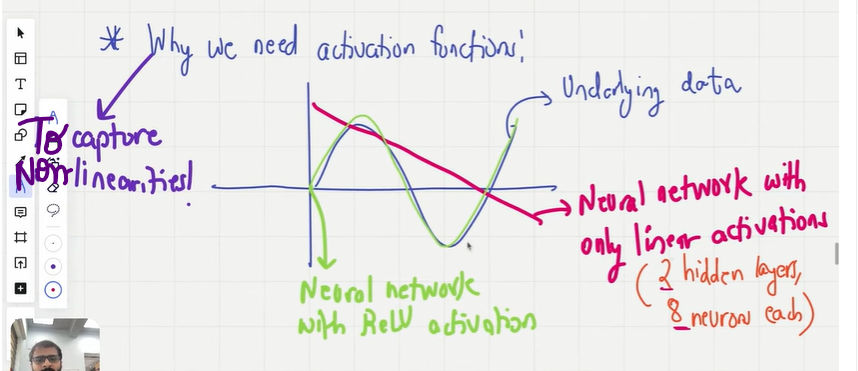

In [5]:
from IPython.display import Image
Image(filename='why_we_need_activation_function_image.png', width=300) 

We dont want the pink line here, that represents linearity, a simple regression does that, we want to work on non linear data, hence we add non linearity using activation functions

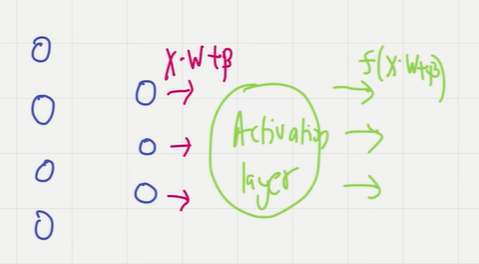

In [15]:
Image(filename='working_nn.png', width=300) 
#this neural network consists of 4 inouts and 3 neurons and in the image below we understand that everylayer is passed 
#through the activation layer before being transfered to next layer as input. 

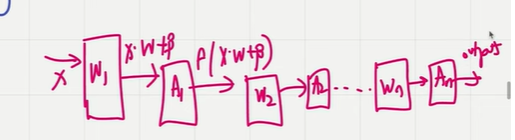

In [17]:
Image(filename='activation_in_nn.png', width=300) 
#below is the blockdiagram of activation functions.

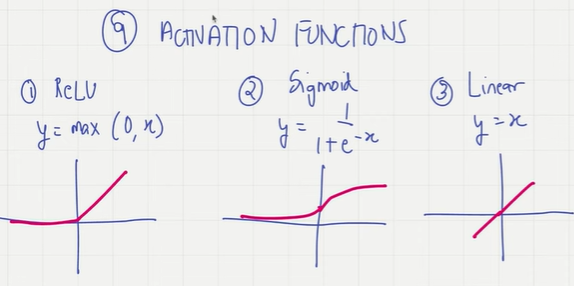

In [21]:
#Lets now look into different activation functions.
Image(filename='functions_graph.png', width=300) 

One of the most famous activation function is:
1) RELU(Rectified Linear Unit):
   here, y=max(0,x)
   how is this small change, so significant and powerful?
   without relu, we have a linear graph. but in complex cases our underlying data can result into non linear graphs, the following is how
   playing with relu can result in the desired graph.

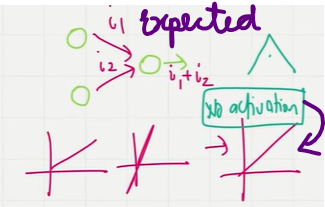

In [23]:
Image(filename='exp_no_act.png', width=300) 
#WITHOUT ACTIVATION

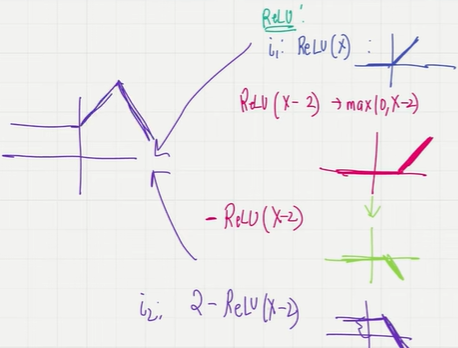

In [25]:
#WITH ACTIVATION
Image(filename='relu.png', width=300) 

In [27]:
#In the next Example we will see how playing with relu can form a sign graph. 
from IPython.display import Video
Video("relu_flow.mp4", width=600)


In [37]:
#Implementing RELU
from CLASSES import Layer_Dense

inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]
output = np.maximum(0, inputs)
print(output)

# ReLU activation also created in CLASSES.py
class Activation_ReLU:
 # Forward pass
 def forward(self, inputs):
 # Calculate output values from input
  self.output = np.maximum(0, inputs)

# Create dataset
import nnfs
from nnfs.datasets import spiral_data
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Make a forward pass of our training data through this layer
dense1.forward(X)
# Forward pass through activation func.
# Takes in output from previous layer
activation1.forward(dense1.output)
# Let's see output of the first few samples:
print(activation1.output[:5])

[0.  2.  0.  3.3 0.  1.1 2.2 0. ]
[[0.         0.         0.        ]
 [0.00013767 0.         0.        ]
 [0.00022187 0.         0.        ]
 [0.0004077  0.         0.        ]
 [0.00054541 0.         0.        ]]


OK, so the data given to us is spiral data, and we have to perform classification, RELU is not the best activation
function to perform classification. In the case of our spiral data classification, we need to determine, whether the data point with x1,x2 is part of blue class? red class? or green class? which is a multiclass classification, and for that we want the outputs to sum up to 1. and come out in probabilities to detemine the point lies in which class, highest probability class. 

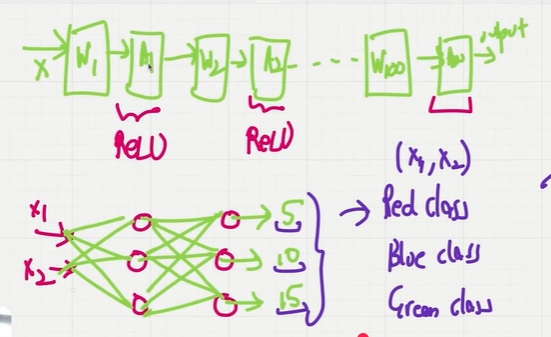

In [39]:
#HOW RELU GIVES OUTPUT, its numbers like 5, 10, 15 which can not determine 1 class.
Image(filename='ONLYRELU.png', width=300) 

So, we can either use another activation function throughout the layers, or just at the end output layer so the outputs are between 0 and 1 and
are in the forms of probabilities.
The activation function for that is the-

-SOFTMAX ACTIVATION FUNCTION
-
It uses exponenting the normalised data that we achieve after subtracting max value from each row. and then that exponential value is divided by sum of exponents to result into probabilities. for the above case. the softmax outputs of the relu outputs will be as follows:

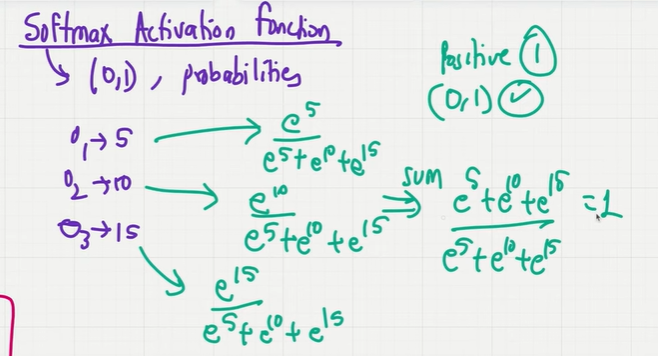

In [41]:
Image(filename='relu+softmax.png', width=300) 
#sum is 1 as it should be for 3 probabilities.

In [43]:
#Another example for Softmax function is
inputs = [[1, 2, 3, 2.5],
 [2., 5., -1., 2],
 [-1.5, 2.7, 3.3, -0.8]]

# Get unnormalized probabilities
exp_values = np.exp(inputs - np.max(inputs, axis=1,keepdims=True))
 # Normalize them for each sample
probabilities = exp_values / np.sum(exp_values, axis=1,keepdims=True)
print(probabilities)
np.sum(probabilities, axis = 1)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


array([1., 1., 1.])

In [45]:
# Softmax activation, also created in CLASSES.py
class Activation_Softmax:
 # Forward pass
 def forward(self, inputs):
 # Get unnormalized probabilities
  exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
 # Normalize them for each sample
  probabilities = exp_values / np.sum(exp_values, axis=1,keepdims=True)
  self.output = probabilities

The below is how, the initial layers are outputting using RELU, but the output layer uses the SOFTMAX function to result in probabilities, for classification purposes.

In [47]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
#this dense lyer class is imported from CLASSES file in the folder saved as CLASSES. it contains all the default made classes. 
dense2 = Layer_Dense(3, 3)
# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()

# Make a forward pass of our training data through this layer
dense1.forward(X)

# Make a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(dense1.output)
# Make a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)
# Make a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(dense2.output)
# Let's see output of the first few samples:
print(activation2.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333302 0.3333336 ]
 [0.33333337 0.3333327  0.33333397]
 [0.33333334 0.33333296 0.33333364]
 [0.3333334  0.33333302 0.33333358]]
